In [96]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

## Data Acquisition

In [80]:
data = pd.read_csv(filepath_or_buffer ="https://raw.githubusercontent.com/insaid2018/Term-3/master/Data/CaseStudy/glass.csv") 
print(f"shape of the data ::: {data.shape}")

shape of the data ::: (214, 10)


In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [82]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [83]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [84]:
data.skew()

RI      1.625431
Na      0.454181
Mg     -1.152559
Al      0.907290
Si     -0.730447
K       6.551648
Ca      2.047054
Ba      3.416425
Fe      1.754327
Type    1.114915
dtype: float64

## Removal Of Duplicate Records

In [85]:
data.duplicated().any()

True

In [86]:
duplicate_records = data[data.duplicated()]

In [87]:
data = data.drop_duplicates()
data.shape

(213, 10)

## Exploratory Data Analysis

Distribution of types of Glasses.

In [88]:
data['Type'].value_counts()

2    76
1    69
7    29
3    17
5    13
6     9
Name: Type, dtype: int64

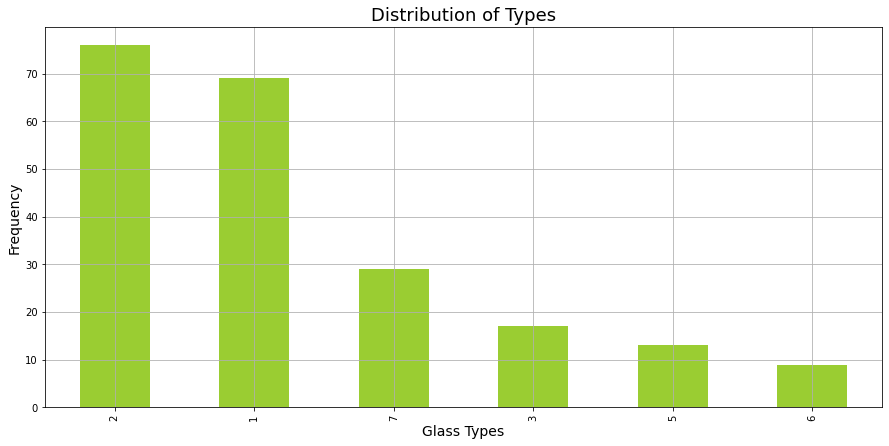

In [89]:
paper = plt.figure(figsize=[15,7])
data['Type'].value_counts().plot.bar(color='yellowgreen')
plt.xlabel("Glass Types",size=14)
plt.ylabel("Frequency",size=14)
plt.title("Distribution of Types",size=18)
plt.grid(visible=True)
plt.show()

## Model Building

In [90]:
X = data.drop(labels ='Type',axis = 1)
y = data['Type']
print(f"X.shape ::: {X.shape}")
print(f"y.shape ::: {y.shape}")

X.shape ::: (213, 9)
y.shape ::: (213,)


In [91]:
my_features = data.columns
my_features = my_features[:-1]
print(my_features)

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'], dtype='object')


In [92]:
print(y.head(10))

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: Type, dtype: int64


In [93]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X,y)
sc_X = pd.DataFrame(data=scaled_data ,columns=my_features)
sc_X.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.879840,0.289558,1.257238,-0.706370,-1.133248,-0.673480,-0.143466,-0.353808,-0.588301
1,-0.243816,0.596403,0.639311,-0.180863,0.097037,-0.028962,-0.790201,-0.353808,-0.588301
2,-0.716412,0.154546,0.604596,0.182950,0.433746,-0.167073,-0.825349,-0.353808,-0.588301
3,-0.227291,-0.238216,0.701798,-0.322346,-0.058368,0.109149,-0.516041,-0.353808,-0.588301
4,-0.306608,-0.164573,0.653197,-0.423405,0.550299,0.078457,-0.621487,-0.353808,-0.588301


In [94]:
X_train, X_test, y_train, y_test = train_test_split(sc_X, y, test_size=0.30, random_state=42)
print(f"X_train.shape ::: {X_train.shape}")
print(f"X_test.shape ::: {X_test.shape}")
print(f"y_train.shape ::: {y_train.shape}")
print(f"y_test.shape ::: {y_test.shape}")

X_train.shape ::: (149, 9)
X_test.shape ::: (64, 9)
y_train.shape ::: (149,)
y_test.shape ::: (64,)


In [124]:
knc = KNeighborsClassifier(n_neighbors=5,metric="euclidean",n_jobs=-1)
knc.fit(X_train,y_train)
y_train_pred = knc.predict(X_train)
y_test_pred = knc.predict(X_test)

In [125]:
print("******Train Data*******")
train_acc = accuracy_score(y_train, y_train_pred)
print(train_acc)
print("******Test Data********")
test_acc = accuracy_score(y_test, y_test_pred)
print(test_acc)

******Train Data*******
0.7248322147651006
******Test Data********
0.703125


## GridSearch CV

In [126]:
param_grid_knn = {'n_neighbors': list(range(2, 20)),
                  'metric': ['minkowski',],
                  'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                  'p': list(range(1,6)),
                  'weights': ["uniform", "distance"]}

clfs = KNeighborsClassifier(n_jobs=-1).fit(X_train,y_train)
cv = GridSearchCV(estimator=clfs, param_grid=param_grid_knn, cv= 5)
cv.fit(X_train, y_train)
y_pred_train = clfs.predict(X_train)
y_pred_test = clfs.predict(X_test)

In [127]:
print("******Train Data*******")
train_acc1 = accuracy_score(y_train, y_pred_train)
print(train_acc1)
print("******Test Data********")
test_acc1 = accuracy_score(y_test, y_pred_test)
print(test_acc1)

******Train Data*******
0.7248322147651006
******Test Data********
0.703125
